# Population method debug
Current SII-population is not working well: we get more negative than positive values


In [33]:
import os
from collections import Counter
from math import log
import csv
from utils import DATA_DIR
from pathlib import Path
import ast
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt

path_to_tensors = Path(DATA_DIR) / "test/tensors"
path_to_vectors = Path(DATA_DIR) / "vectors/karrewiet_vectors_ids.csv"


In [34]:
if not path_to_tensors:
    # dataset = path_to_vectors.split("/")[-1].split(".")[0]
    # path_to_tensors = DATA_DIR/f"tensors/{dataset}/"
    dataset = path_to_vectors.stem.split('_')[0]+"_sparse"  # instead of split()
    print(f"Dataset name inferred as: {dataset}")
    path_to_tensors = DATA_DIR / f"tensors/{dataset}/"

os.makedirs(path_to_tensors, exist_ok=True)
os.makedirs(f"{path_to_tensors}/populated", exist_ok=True)
os.makedirs(f"{path_to_tensors}/vocabularies", exist_ok=True)
print(f"Tensors will be saved to {path_to_tensors}")


p_x = Counter()  # probabilities
p_y = Counter()
p_z = Counter()
p_xy = Counter()
p_yz = Counter()
p_xz = Counter()
p_xyz = Counter()

def specific_interaction_information(x, y, z):
    if min(p_x[x], p_y[y], p_z[z], p_xy[(x, y)], p_yz[(y, z)], p_xz[(x, z)], p_xyz[(x, y, z)]) == 0:
        raise ValueError('One of the probabilities is zero, cannot compute SII')
    sii = log(
        (p_xy[(x, y)] * p_yz[(y, z)] * p_xz[(x, z)])
        /
        (p_x[x] * p_y[y] * p_z[z] * p_xyz[(x, y, z)])
    )
    return sii

def specific_correlation(x, y, z):
    if min(p_x[x], p_y[y], p_z[z], p_xyz[(x, y, z)]) == 0:
        raise ValueError('One of the probabilities is zero, cannot compute SC')
    sc = log(
        p_xyz[(x, y, z)]
        /
        (p_x[x] * p_y[y] * p_z[z])
    )
    return sc



Tensors will be saved to /home/local/stefa/data/test/tensors


In [35]:
vectors = []

p_x = Counter()  # probabilities
p_y = Counter()
p_z = Counter()
p_xy = Counter()
p_yz = Counter()
p_xz = Counter()
p_xyz = Counter()

with open(path_to_vectors, "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    next(reader, None)  # skip header if there is one
    for row in reader:
        vector = row[1]
        # vector is a string representation of a tuple, we convert it back to tuple
        vector = tuple(vector.strip("()").replace("'", "").split(", "))
        (v, s, o) = vector[:3]
        v = v or "~"
        s = s or "~"
        o = o or "~"
        vectors.append((v, s, o))

        p_x[v] += 1
        p_y[s] += 1
        p_z[o] += 1
        p_xy[(v, s)] += 1
        p_yz[(s, o)] += 1
        p_xz[(v, o)] += 1
        p_xyz[(v, s, o)] += 1

In [36]:
pres = None in p_y.keys()
if pres:
    print("None:", p_y[None])
else:
    print("None: False")
pres = 'None' in p_y.keys()
if pres:
    print("'None':", p_y['None'])
else:
    print("'None': False")

pres = '~' in p_y.keys()
if pres:
    print("'~':", p_y['~'])
else:
    print("'~': False")

None: False
'None': 25717
'~': False


In [37]:
vectors = []

p_x = Counter()  # probabilities
p_y = Counter()
p_z = Counter()
p_xy = Counter()
p_yz = Counter()
p_xz = Counter()
p_xyz = Counter()
with open(path_to_vectors, "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    next(reader, None)  # skip header if there is one
    for row in reader:
        # vector = row[1]
        # vector is a string representation of a tuple, we convert it back to tuple
        vector = ast.literal_eval(row[1])
        (v, s, o) = vector[:3]
        v = v or "~"
        s = s or "~"
        o = o or "~"
        vectors.append((v, s, o))

        p_x[v] += 1
        p_y[s] += 1
        p_z[o] += 1
        p_xy[(v, s)] += 1
        p_yz[(s, o)] += 1
        p_xz[(v, o)] += 1
        p_xyz[(v, s, o)] += 1

In [38]:
pres = None in p_y.keys()
if pres:
    print("None:", p_y[None])
else:
    print("None: False")
pres = 'None' in p_y.keys()
if pres:
    print("'None':", p_y['None'])
else:
    print("'None': False")
pres = '~' in p_y.keys()
if pres:
    print("'~':", p_y['~'])
else:
    print("'~': False")

None: False
'None': False
'~': 25717


In [39]:
total_len = len(vectors)
# convert all counts to probabilities in place
for counter in [p_x, p_y, p_z, p_xy, p_yz, p_xz, p_xyz]:
    for key in counter:
        counter[key] /= total_len
print("Probabilities computed.")

Probabilities computed.


In [40]:
results = {}
top_k = 1000
to_compute = {"counting", "sii", "sc", "vocabularies"}

m_c_v = [v for (v, count) in p_x.most_common(top_k)]
m_c_s = [s for (s, count) in p_y.most_common(top_k)]
m_c_o = [o for (o, count) in p_z.most_common(top_k)]
# we check if all have at least top_k counts
if not len(m_c_v) == len(m_c_s) == len(m_c_o) == top_k:
    print(f"Warning: less than {top_k} unique elements in one of the dimensions.")

# use top-k directly as vocabs
vocab_v = m_c_v
vocab_s = m_c_s
vocab_o = m_c_o

V, S, O = len(vocab_v), len(vocab_s), len(vocab_o)

v2i = {v: i for i, v in enumerate(vocab_v)}
s2i = {s: i for i, s in enumerate(vocab_s)}
o2i = {o: i for i, o in enumerate(vocab_o)}

# for filtering triples, use sets for fast membership
v_set = set(vocab_v)
s_set = set(vocab_s)
o_set = set(vocab_o)


In [41]:
subset_t = []
for v, s, o in vectors:
    if v in v_set and s in s_set and o in o_set:
        subset_t.append((v, s, o))

total_size = V * S * O
print(f"Tensor dims: V={V}, S={S}, O={O}")
print(f"Dense size: {total_size} entries (~{(V * S * O * 4) / (1024 ** 3):.2f} GB as float32)")


Tensor dims: V=1000, S=1000, O=1000
Dense size: 1000000000 entries (~3.73 GB as float32)


In [42]:
# --- NEW: build sparse representation directly ---
triple_counts = Counter(subset_t)

indices = []
count_values = []
sii_values = []
sc_values = []

for (v, s, o), count in tqdm(triple_counts.items()):
    vi = v2i[v]
    si = s2i[s]
    oi = o2i[o]

    # store indices (vi, si, oi)
    indices.append([vi, si, oi])
    count_values.append(float(count))

    # these may raise ValueError if some probability is zero (same behavior as before)
    sii_values.append(float(specific_interaction_information(v, s, o)))
    sc_values.append(float(specific_correlation(v, s, o)))

100%|██████████| 30462/30462 [00:00<00:00, 290612.44it/s]


In [43]:
# we check for positive, negative and zero values in count, sii and sc
names = ["count", "sii", "sc"]
for i, values in enumerate([count_values, sii_values, sc_values]):
    zero = sum(x == 0 for x in values)
    positives = sum(x > 0 for x in values)
    negatives = sum(x < 0 for x in values)
    print(f"{names[i]}\nOut of {len(values)}:\nzero: {zero}\npositives: {positives}\nnegatives: {negatives}\n\n")


count
Out of 30462:
zero: 0
positives: 30462
negatives: 0


sii
Out of 30462:
zero: 0
positives: 10114
negatives: 20348


sc
Out of 30462:
zero: 0
positives: 28120
negatives: 2342




In [44]:
if len(indices) == 0:
    # no non-zero entries; create empty sparse tensors
    indices_tensor = torch.empty((3, 0), dtype=torch.long)
    count_tensor = torch.sparse_coo_tensor(indices_tensor,
                                           torch.empty((0,), dtype=torch.float32),
                                           size=(V, S, O))
    sii_tensor = torch.sparse_coo_tensor(indices_tensor,
                                         torch.empty((0,), dtype=torch.float32),
                                         size=(V, S, O))
    sc_tensor = torch.sparse_coo_tensor(indices_tensor,
                                        torch.empty((0,), dtype=torch.float32),
                                        size=(V, S, O))
else:
    indices_tensor = torch.tensor(indices, dtype=torch.long).t()  # shape (3, nnz)
    count_values_tensor = torch.tensor(count_values, dtype=torch.float32)
    sii_values_tensor = torch.tensor(sii_values, dtype=torch.float32)
    sc_values_tensor = torch.tensor(sc_values, dtype=torch.float32)

    size = (V, S, O)

    count_tensor = torch.sparse_coo_tensor(indices_tensor, count_values_tensor, size=size)
    sii_tensor = torch.sparse_coo_tensor(indices_tensor, sii_values_tensor, size=size)
    sc_tensor = torch.sparse_coo_tensor(indices_tensor, sc_values_tensor, size=size)

    # ensure canonical form (sorted indices, summed duplicates)
    count_tensor = count_tensor.coalesce()
    sii_tensor = sii_tensor.coalesce()
    sc_tensor = sc_tensor.coalesce()

In [45]:
# get COO components
idx = sii_tensor.indices()   # shape (3, nnz)
vals = sii_tensor.values()   # shape (nnz,)
k = 50

topk_vals, topk_pos = torch.topk(vals, k=k, largest=True)
bottomk_vals, bottomk_pos = torch.topk(vals, k=k, largest=False)

def decode_entries(positions, values):
    decoded = []
    for pos, val in zip(positions.tolist(), values.tolist()):
        v_i, s_i, o_i = idx[:, pos].tolist()
        decoded.append({
            "sii": val,
            "indices": (v_i, s_i, o_i),
            "tuple": (vocab_v[v_i], vocab_s[s_i], vocab_o[o_i]),
        })
    return decoded

top_50 = decode_entries(topk_pos, topk_vals)
bottom_50 = decode_entries(bottomk_pos, bottomk_vals)


In [46]:
print("\nTop 50 lowest SII values:\n")
for i, entry in enumerate(bottom_50, 1):
    print(
        f"{i:02d}. SII={entry['sii']:.6f} | "
        f"indices={entry['indices']} | "
        f"tuple={entry['tuple']}"
    )
print("\nTop 50 highest SII values:\n")
for i, entry in enumerate(top_50, 1):
    print(
        f"{i:02d}. SII={entry['sii']:.6f} | "
        f"indices={entry['indices']} | "
        f"tuple={entry['tuple']}"
    )


Top 50 lowest SII values:

01. SII=-6.852052 | indices=(22, 17, 20) | tuple=('laten', 'wie', 'naam')
02. SII=-6.609967 | indices=(154, 1, 89) | tuple=('verzamelen', 'ik', 'stem')
03. SII=-6.513087 | indices=(19, 21, 1) | tuple=('winnen', 'school', 'dat')
04. SII=-6.345295 | indices=(311, 6, 2) | tuple=('opgeven', 'dat', 'het')
05. SII=-6.342630 | indices=(120, 6, 65) | tuple=('oefenen', 'dat', 'hand')
06. SII=-6.280757 | indices=(40, 6, 2) | tuple=('kennen', 'dat', 'het')
07. SII=-6.271956 | indices=(32, 20, 10) | tuple=('nemen', 'politie', 'ze')
08. SII=-6.172297 | indices=(80, 6, 3) | tuple=('noemen', 'dat', 'wat')
09. SII=-6.066865 | indices=(55, 37, 1) | tuple=('betekenen', 'regering', 'dat')
10. SII=-6.014503 | indices=(24, 7, 5) | tuple=('vragen', 'het', 'veel')
11. SII=-5.973979 | indices=(92, 14, 9) | tuple=('verkopen', 'zij', 'ding')
12. SII=-5.969054 | indices=(122, 6, 94) | tuple=('openen', 'dat', 'weg')
13. SII=-5.938311 | indices=(4, 31, 14) | tuple=('doen', 'dit', 'je')


## Ensuring SII remains positive
2 options:
+ Min-max shifting
    + Subtract lowest value from all values: if negative -> + makes everything at least positive
    + Retains interpretability
+ Softplus
    + Implemented in torch
    + Stable, bounded and smooth that leaves high values almost intact, and pushes low values close to zero

Old min/max: -6.852051734924316 7.1300458908081055
New min/max: 9.99999993922529e-09 13.982097625732422


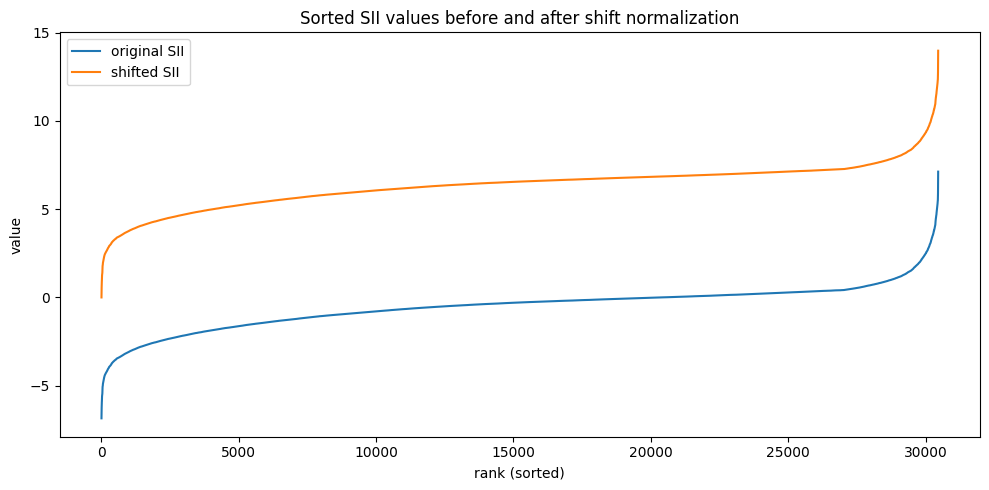

In [47]:

vals = sii_tensor.values()

min_val = vals.min()
eps = 1e-8  # small positive floor

norm_vals = vals - min_val + eps

sii_tensor_norm = torch.sparse_coo_tensor(
    sii_tensor.indices(),
    norm_vals,
    size=sii_tensor.size()
).coalesce()
print("Old min/max:", vals.min().item(), vals.max().item())
print("New min/max:", norm_vals.min().item(), norm_vals.max().item())

# we plot the values
vals_sorted, _ = torch.sort(vals)
norm_sorted, _ = torch.sort(norm_vals)

plt.figure(figsize=(10, 5))
plt.plot(vals_sorted.numpy(), label="original SII")
plt.plot(norm_sorted.numpy(), label="shifted SII")

plt.xlabel("rank (sorted)")
plt.ylabel("value")
plt.legend()
plt.title("Sorted SII values before and after shift normalization")

plt.tight_layout()
plt.show()

Old min/max: -6.852051734924316 7.1300458908081055
New min/max: 0.00105672562494874 7.1308465003967285


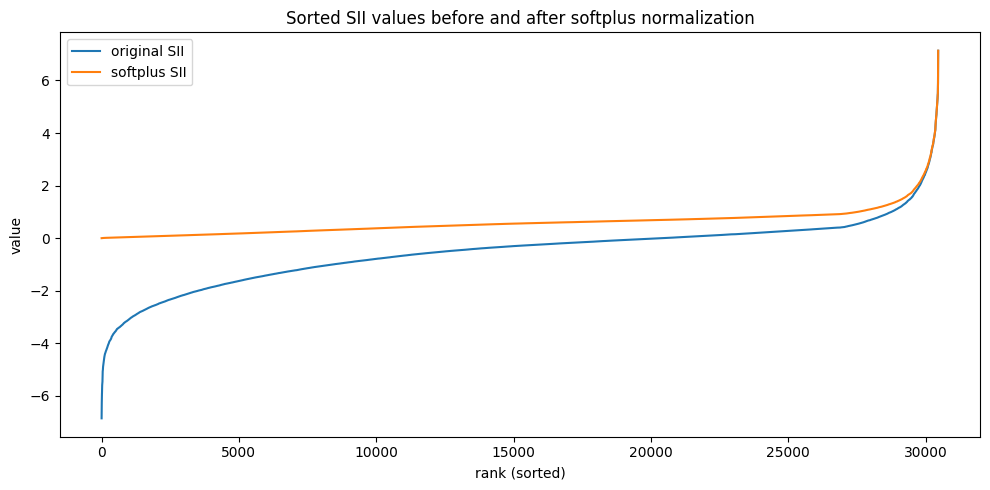

In [48]:
norm_vals = torch.nn.functional.softplus(vals)

sii_tensor_norm = torch.sparse_coo_tensor(
    sii_tensor.indices(),
    norm_vals,
    size=sii_tensor.size()
).coalesce()
print("Old min/max:", vals.min().item(), vals.max().item())
print("New min/max:", norm_vals.min().item(), norm_vals.max().item())
# we plot the values

vals_sorted, _ = torch.sort(vals)
norm_sorted, _ = torch.sort(norm_vals)

plt.figure(figsize=(10, 5))
plt.plot(vals_sorted.numpy(), label="original SII")
plt.plot(norm_sorted.numpy(), label="softplus SII")

plt.xlabel("rank (sorted)")
plt.ylabel("value")
plt.legend()
plt.title("Sorted SII values before and after softplus normalization")

plt.tight_layout()
plt.show()
